## Import Modules




In [10]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from simpeg import maps
from simpeg.potential_fields import gravity
from simpeg.utils import model_builder
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)

from plots import plot_density_model, plot_gravity_anomaly


## Topography Generation
(N, 3) array




In [11]:
[x_topo, y_topo] = np.meshgrid(np.linspace(-200, 200, 41), np.linspace(-200, 200, 41))
z_topo = -15 * np.exp(-(x_topo**2 + y_topo**2) / 80**2)
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[x_topo, y_topo, z_topo] 

## Tensor Mesh Generation

In [12]:
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

## Mapping (True) Density Contrast

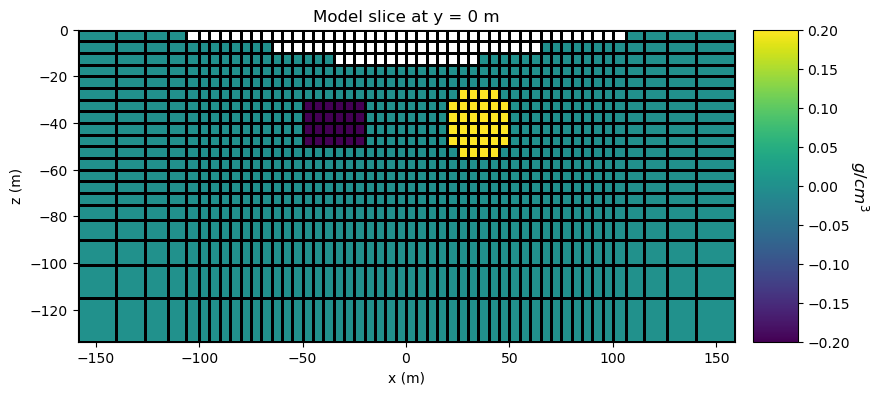

In [13]:
# Density contrast
background_density = 0.0  #g/cc
block_density = -0.2  #g/cc
sphere_density = 0.2  #g/cc

# Define indices of cells above & below surface (earth & air)
ind_active = active_from_xyz(mesh, topo_xyz)
nC = int(ind_active.sum())
model_map = maps.IdentityMap(nP=nC)
true_model = background_density * np.ones(nC)

# Define the block
ind_block = (
    (mesh.gridCC[ind_active, 0] > -50.0)
    & (mesh.gridCC[ind_active, 0] < -20.0)
    & (mesh.gridCC[ind_active, 1] > -15.0)
    & (mesh.gridCC[ind_active, 1] < 15.0)
    & (mesh.gridCC[ind_active, 2] > -50.0)
    & (mesh.gridCC[ind_active, 2] < -30.0)
)
true_model[ind_block] = block_density

# Define the sphere (SIMPEG utility)
ind_sphere = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, -40.0], 15.0, mesh.gridCC
)
ind_sphere = ind_sphere[ind_active]
true_model[ind_sphere] = sphere_density

# Plot Density Contrast Model
plot_density_model(mesh, ind_active, true_model)

## Defining Survey

(N, 3) array to define the xyz locations and field components
which are to be measured.

In [18]:
# Define the observation locations (N, 3) array
x = np.linspace(-80.0, 80.0, 10)
y = np.linspace(-80.0, 80.0, 10)
x, y = np.meshgrid(x, y)
x, y = mkvc(x.T), mkvc(y.T)
fun_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)
z = fun_interp(np.c_[x, y]) + 5.0
receiver_locations = np.c_[x, y, z]
components = ["gz"]  # z-component of gravity (mGal), downward positive

# Weird SIMPEG library shit...
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]
source_field = gravity.sources.SourceField(receiver_list=receiver_list)
survey = gravity.survey.Survey(source_field)

## Foward (True) Gravity Solution


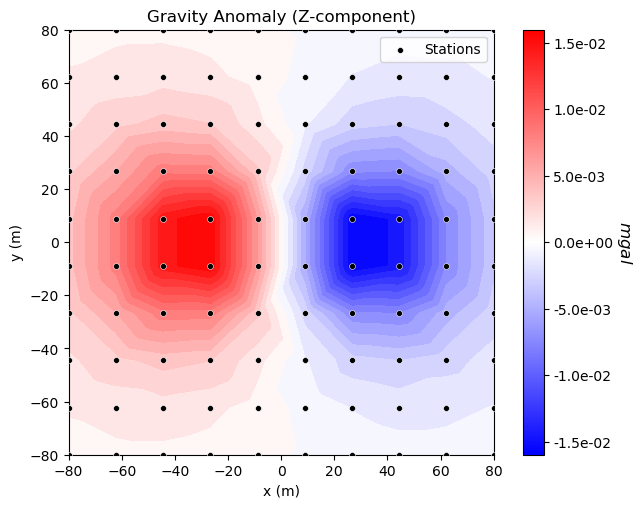

In [20]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,
    active_cells=ind_active,
    store_sensitivities="forward_only",
    engine="choclo",
)

dpred = simulation.dpred(true_model)

# Plot True Gravity 
plot_gravity_anomaly(receiver_list[0].locations, dpred)

## Synthetic Gravity Solution

Adding noise to true gravity solution.

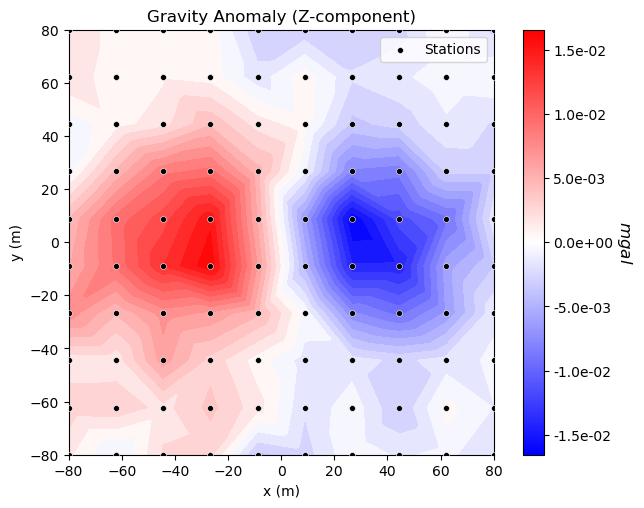

In [23]:
# Initializing Synthetic Desnity Contrast
synthetic_model = np.zeros(nC) 

# build survey + simulation as usual...
syn = simulation.make_synthetic_data(
    true_model,                 # model in g/cc
    relative_error=0.01,        # 1% relative
    noise_floor=0.002,           # 0.02 mGal absolute floor
    add_noise=True,
    random_seed=42
)

dobs = syn.dobs  # noisy data (mGal)
uncertainties = syn.standard_deviation  # per-datum σ (mGal)
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

# Plot Synthetic (Realistic) Gravity 
plot_gravity_anomaly(receiver_list[0].locations, dobs)

## Density Contrast Solver (L2 Norm or IRLS)

Minimize residual + regularization to find density contrast for a given gravitational field.


Running inversion with SimPEG v0.24.0
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver Mumps and no solver_opts.***
                    
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.62e+02  7.74e+02  0.00e+00  7.

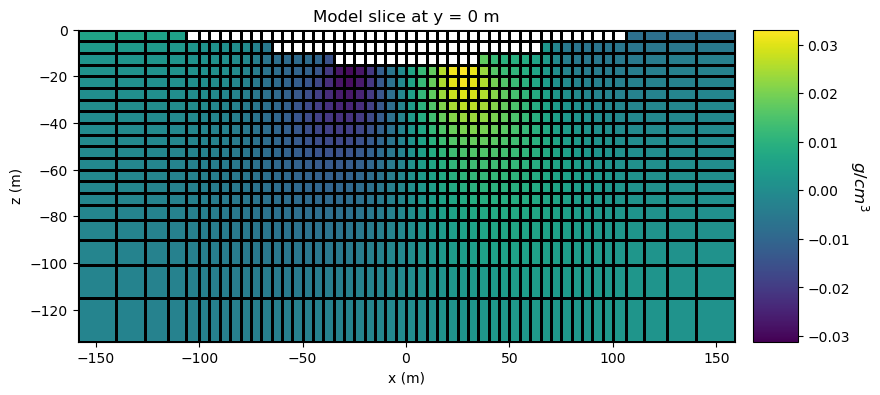

In [24]:
# L2 Norm: ||W(d_pred(m) - d_obs)||^2
dmis = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)  

# Tikhonov regularization (smooths it out) <-- lowkey unrealistic... good for macro density contrast
reg = regularization.WeightedLeastSquares(
    mesh, active_cells=ind_active, mapping=model_map
)

# # Sparse (IRLS) regulatization (encourages sharp features) <-- more realistic
# reg = regularization.Sparse(mesh, active_cells=ind_active, mapping=model_map)
# reg.norms = [0, 2, 2, 2]

# update_IRLS = directives.UpdateIRLS(
#     f_min_change=1e-4,
#     max_irls_iterations=30,
#     irls_cooling_factor=1.5,
#     misfit_tolerance=1e-2,
# )

# Gauss-Newton (Hessian Search)
opt = optimization.ProjectedGNCG(
    maxIter=10, lower=-1.0, upper=1.0, maxIterLS=20, maxIterCG=10, tolCG=1e-3
)

inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=1e1)
beta_schedule = directives.BetaSchedule(coolingFactor=5, coolingRate=1)
save_iteration = directives.SaveOutputEveryIteration(save_txt=False)
update_jacobi = directives.UpdatePreconditioner()
target_misfit = directives.TargetMisfit(chifact=1)
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)

directives_list = [
    sensitivity_weights,
    starting_beta,
    beta_schedule,
    save_iteration,
    update_jacobi,
    target_misfit, # comment out for IRLS
]

inv = inversion.BaseInversion(inv_prob, directives_list)

recovered_model = inv.run(synthetic_model)

plot_density_model(mesh, ind_active, recovered_model)